In [1]:
import os
import scanpy as sc
import cellrank as cr

seed = 52

CWD = os.getcwd()
DATA_PATH = os.path.join(CWD, '10xMouse_velocity_dynamical.h5ad')

In [2]:
adata = sc.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 3528 × 2000
    obs: 'celltype', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'celltype_colors', 'log1p', 'neighbors', 'pca', 'recover_dynamics', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    varm: 'PCs

In [3]:
# Set up velocity kernel and compute the transition Matrix by correlating each cell's velocity vector 
# with the displacement vector towards nearest neighbors 
vk = cr.kernels.VelocityKernel(adata)
vk.compute_transition_matrix()

100%|██████████| 3528/3528 [00:06<00:00, 509.71cell/s]


VelocityKernel[n=3528, model='deterministic', similarity='correlation', softmax_scale=5.107]

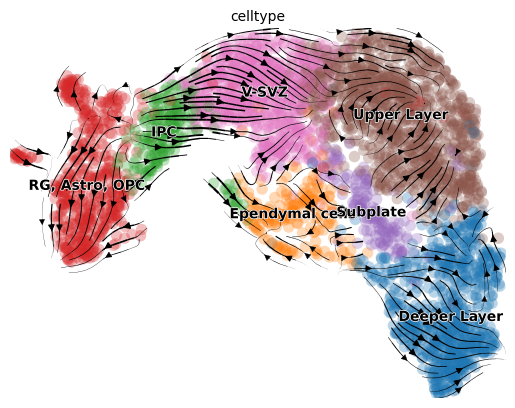

In [4]:
# Visualise transition matrix (quella di scVelo)
vk.plot_projection(color='celltype')

100%|██████████| 200/200 [00:45<00:00,  4.41sim/s]


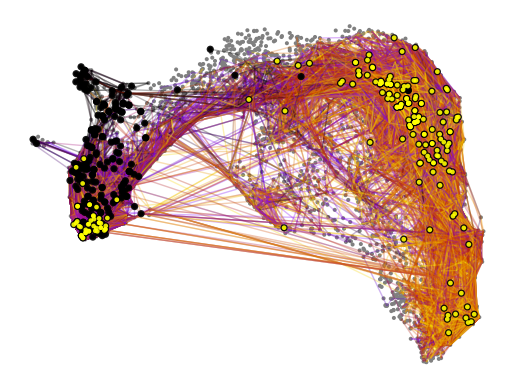

In [5]:
# Simulate a random walk starting in RG, Astro, OPC
# Yellow dots denote end points of RW: OPC, Astrocytes and Deeper Layer
# Black dots denote start points of RW: RG
vk.plot_random_walks(start_ixs={'celltype': 'RG, Astro, OPC'}, n_sims=200, seed = seed, save='RG_starting_RW.png')

In [6]:
# Compute macrostates
# Visualize transition matrix
# Classify Macrostates as initial, terminal or intermediate
g = cr.estimators.GPCCA(vk)

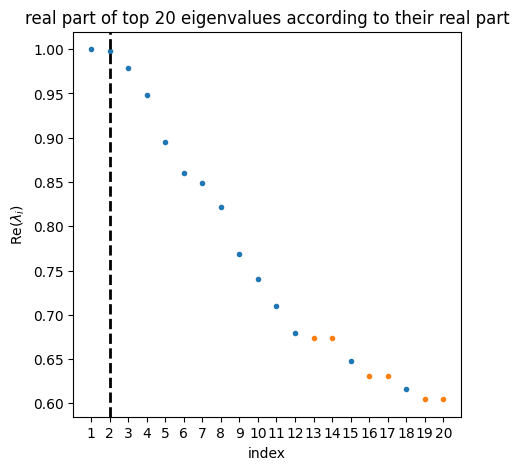

In [7]:
# Fit the estimator by computing Schur decomposition and computed macrostates using GPCCA algorithm 
g.compute_schur()
g.plot_spectrum(save = 'schur_spectrum.png')

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_all_macrostates_2.png


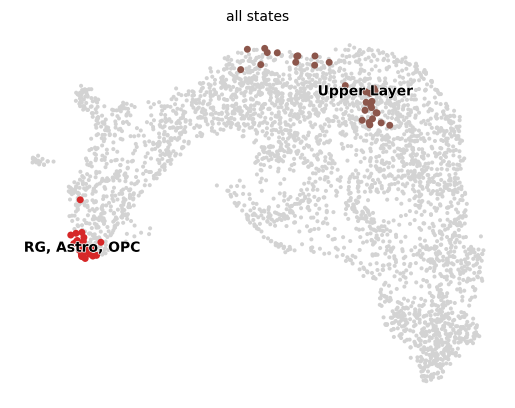

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_terminal_states_2.png


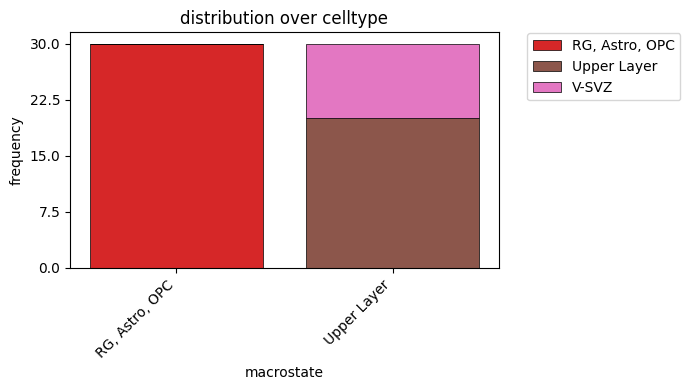

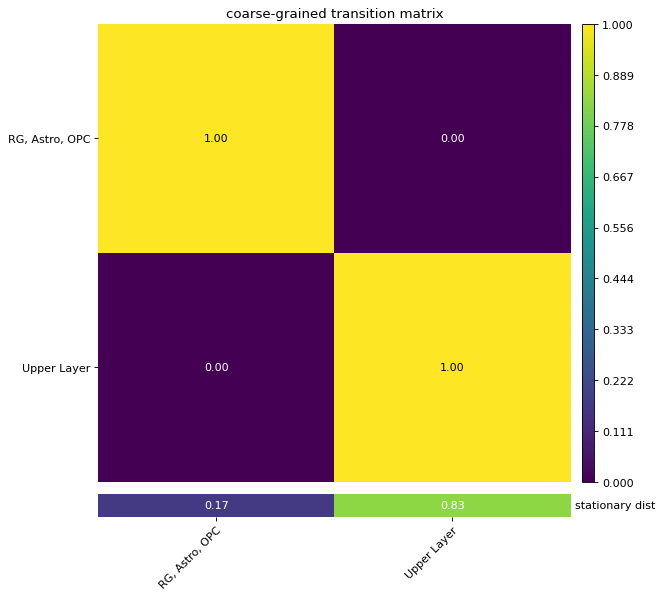

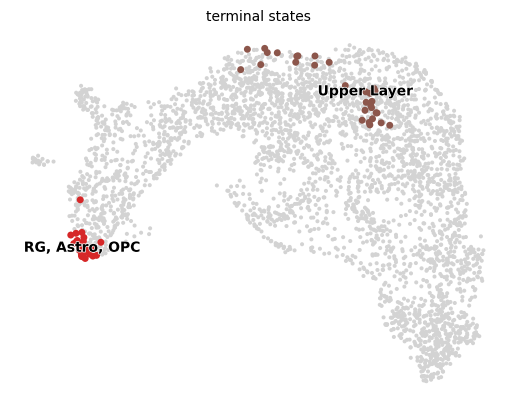

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_initial_states_2.png


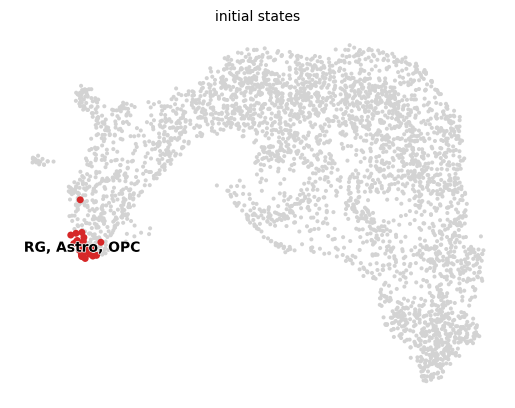

Defaulting to `'gmres'` solver.


100%|██████████| 2/2 [00:00<00:00,  5.32/s]
c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_fate_probabilities_2.png


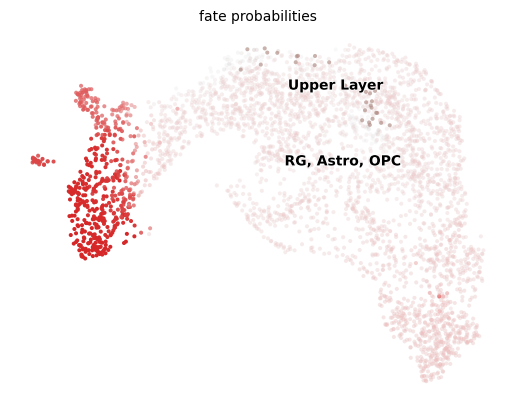

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_all_macrostates_4.png


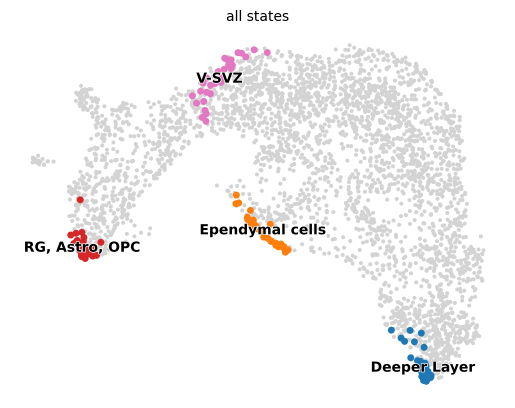

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_terminal_states_4.png


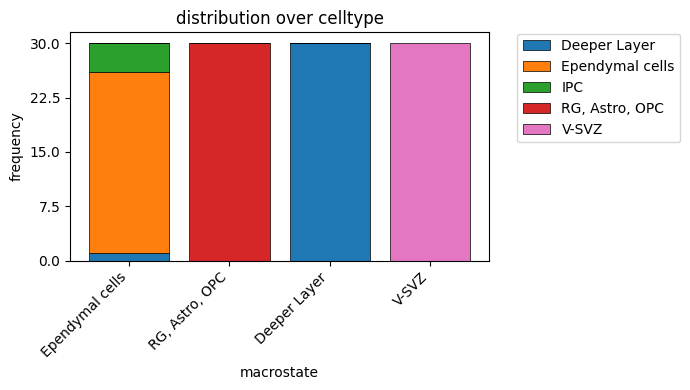

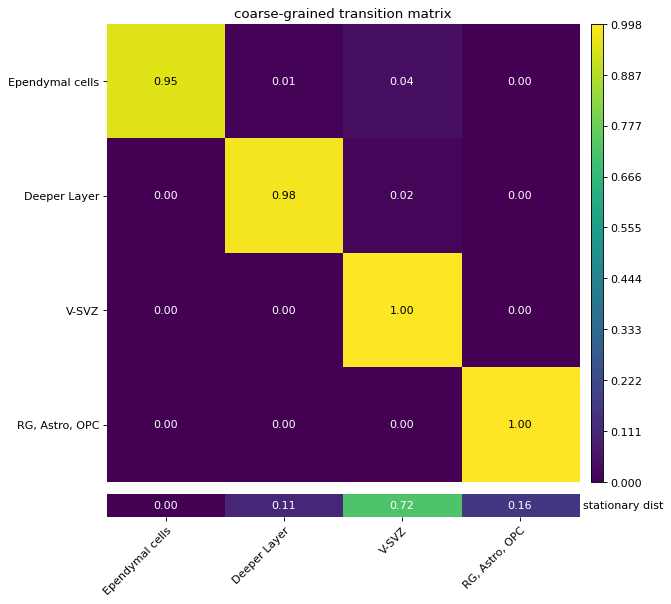

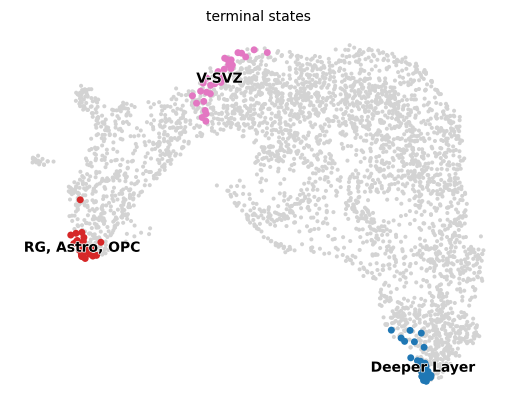

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_initial_states_4.png


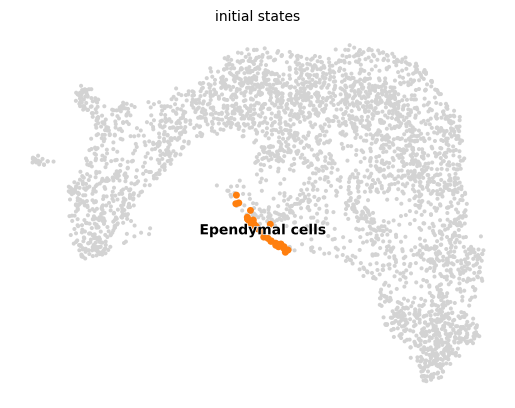

100%|██████████| 3/3 [00:00<00:00,  7.91/s]
c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_fate_probabilities_4.png


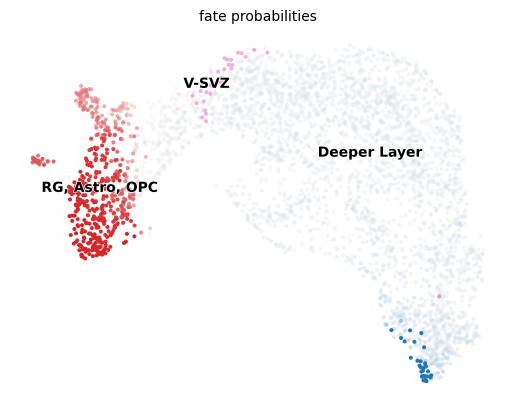

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_all_macrostates_6.png


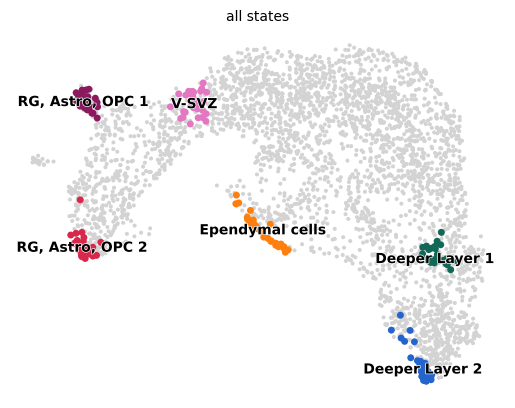

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_terminal_states_6.png


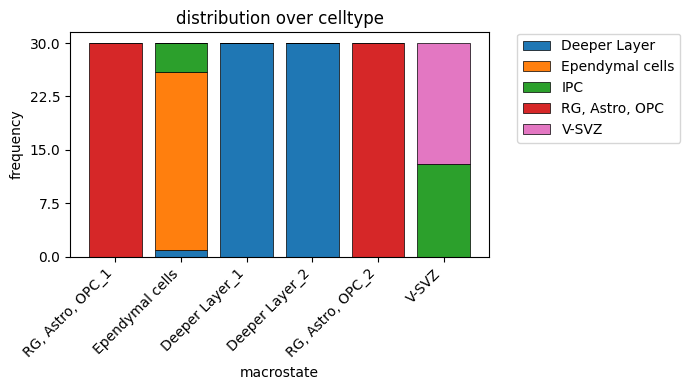

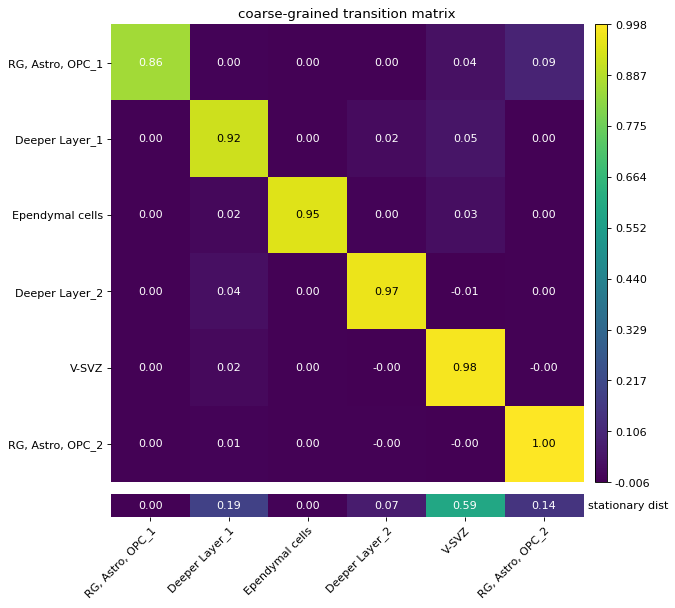

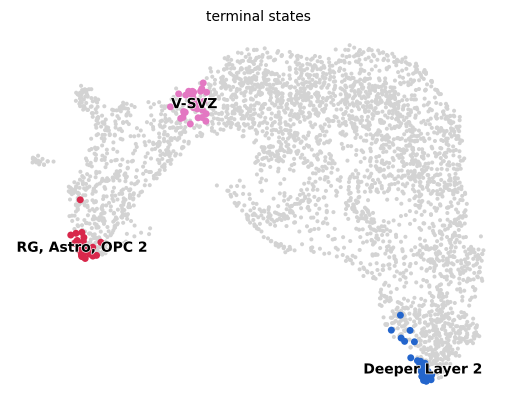

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_initial_states_6.png


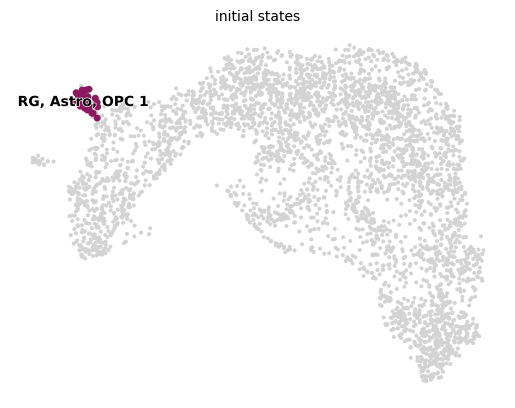

100%|██████████| 3/3 [00:00<00:00,  4.58/s]
c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_fate_probabilities_6.png


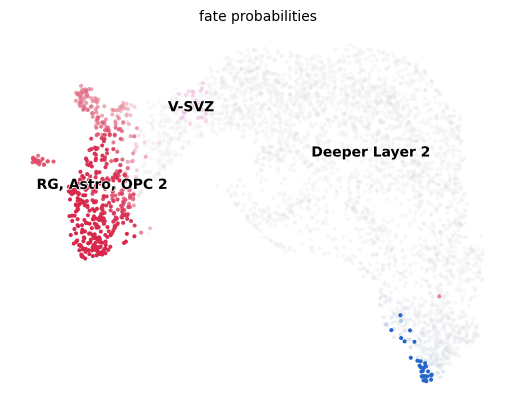

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_all_macrostates_8.png


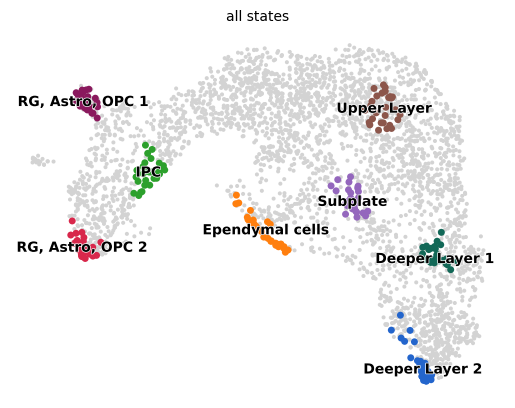

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_terminal_states_8.png


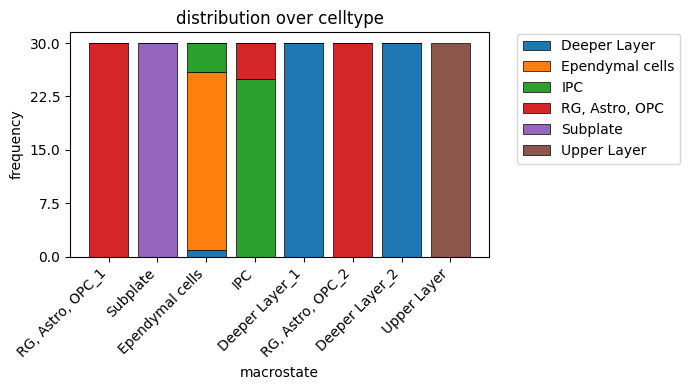

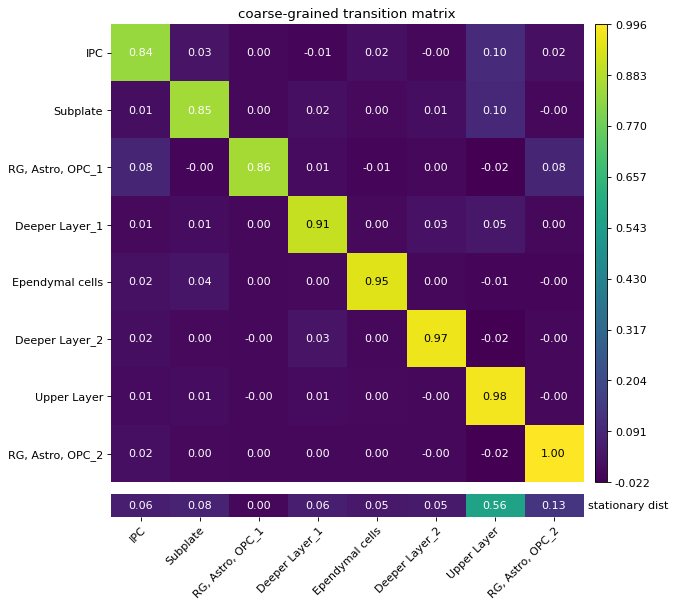

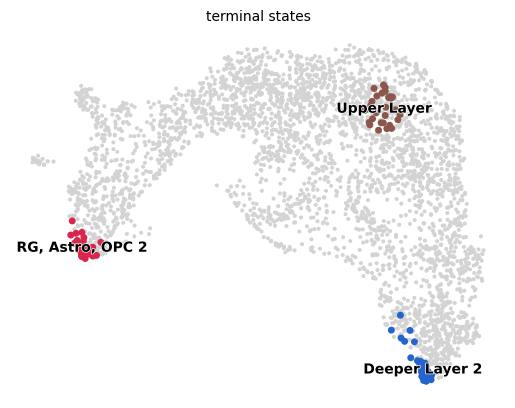

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_initial_states_8.png


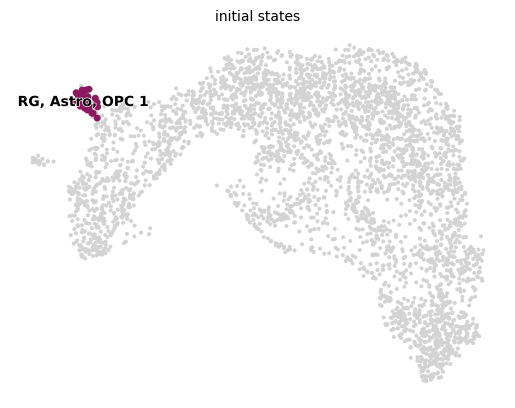

100%|██████████| 3/3 [00:00<00:00,  7.40/s]
c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_fate_probabilities_8.png


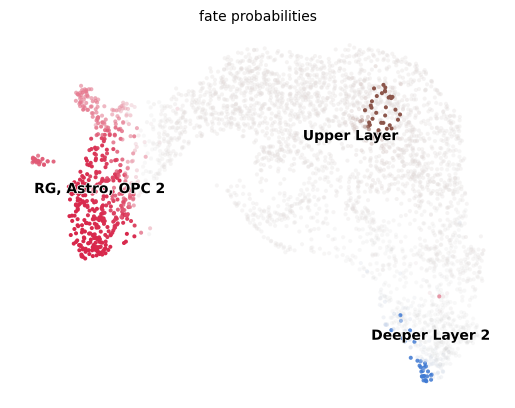

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_all_macrostates_10.png


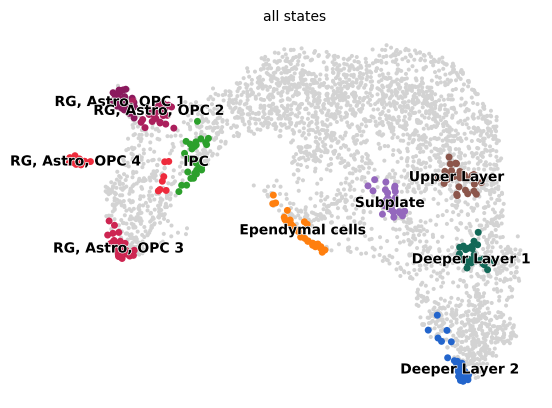

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_terminal_states_10.png


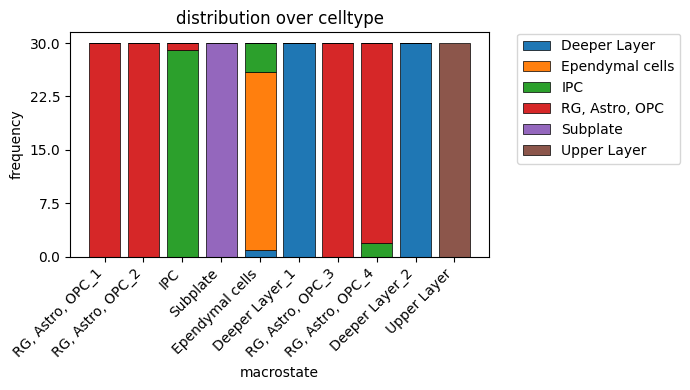

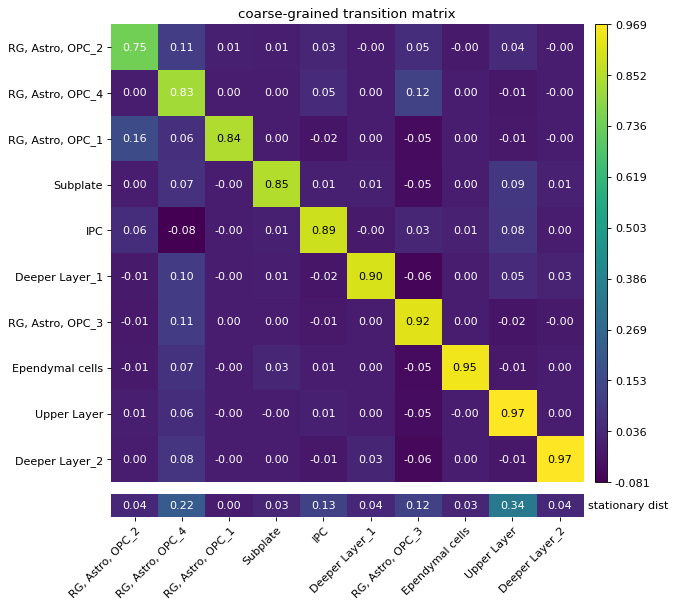

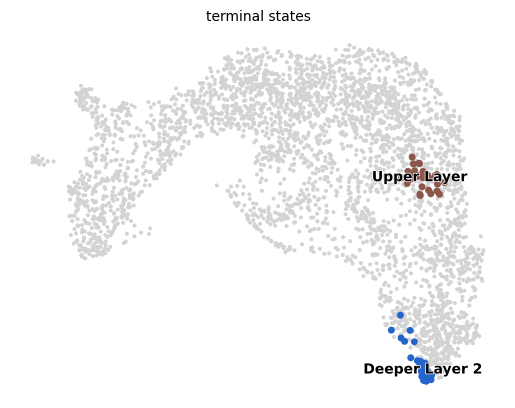

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_initial_states_10.png


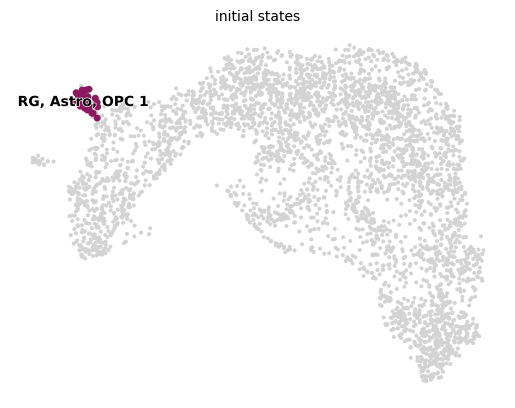

100%|██████████| 2/2 [00:00<00:00,  5.43/s]
c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


saving figure to file ./figures/scvelo_fate_probabilities_10.png


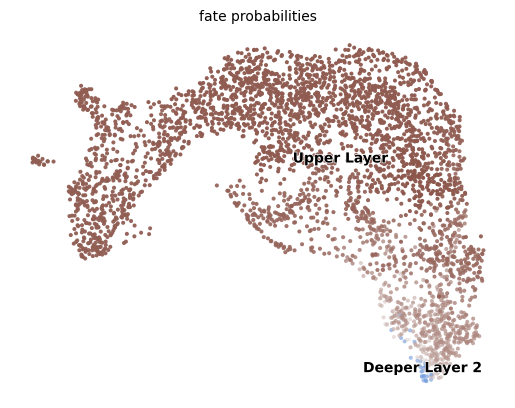

In [8]:
macrostates = list(range(2,11,2))
for n_macro in macrostates:
    # The estimator automatically suggestes a number of states to use (vertical line). 
    # Usually a few more states can be useto identify small cell populations
    g.compute_macrostates(n_states = n_macro, cluster_key='celltype')
    g.plot_macrostates(which='all', s=100, save=f'all_macrostates_{n_macro}.png')
    # We can visualize the relationship between clusters and macrostates
    g.plot_macrostate_composition(key='celltype', figsize=(7,4), save=f'macrostate_composition_{n_macro}.png')
    # Plot the coarse-grained transition matrix 
    g.plot_coarse_T(annotate=True, save = f'coarse_T_{n_macro}.png')
    g.predict_terminal_states()
    g.plot_macrostates(which='terminal', s=100, save =f'terminal_states_{n_macro}.png')
    g.predict_initial_states(allow_overlap=True)
    g.plot_macrostates(which="initial", s=100, save =f'initial_states_{n_macro}.png')
    # Compute fate probabilities
    g.compute_fate_probabilities()
    g.plot_fate_probabilities(same_plot=True, save = f'fate_probabilities_{n_macro}.png')


c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\plotting\scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


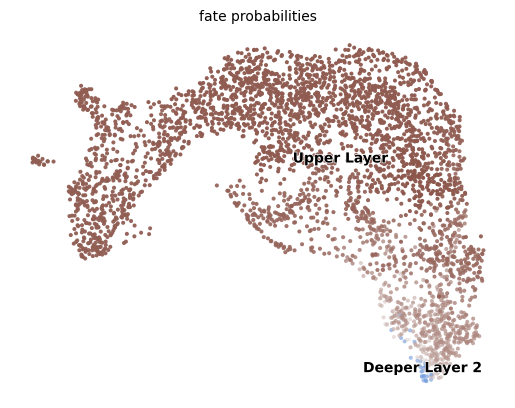

In [9]:
g.plot_fate_probabilities(same_plot=True)